# Spam Email Classification Using Logistic Regression

### Importing needed packages and libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Reading the dataset

#### The source file is TSV (Tab-Separated Values) with no header row, so the separator and column names are set manually.

Dataset source: [SMS Spam Collection — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/228/sms+spam+collection).

In [2]:
df = pd.read_csv('SpamEmailClassification/Email-Spam-Classification/dataset/SMSSpamCollection' , sep="\t" , header= None , names= ['Label' , 'Message'])
df

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### Initial Exploration

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Label    5572 non-null   str  
 1   Message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [4]:
df.describe()

,Label,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
df['Label'].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

**Observation — class imbalance.** The dataset is imbalanced: about 87% of messages are `ham` and only 13% are `spam` (4,825 vs. 747). This is expected for real-world spam data and is why **accuracy alone is not enough** to judge the model — metrics such as F1-score, precision and recall (used later) matter more here, since a naive "always predict ham" model would already score ~87% accuracy without being useful.

### Checking data for missing values and duplicates

In [6]:
df[df.isna()].any(axis= 0)

Label      False
Message    False
dtype: bool

In [7]:
df.isna().sum()

Label      0
Message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

#### Removing duplicates

#### Removing Duplicates

**403 duplicate rows** (identical `Label` + `Message` pairs) were found. These are removed **before** the train/test split — doing it in this order matters: if duplicates were removed *after* splitting, an identical message could still end up in both `X_train` and `X_test`, leaking information between the splits and artificially inflating test performance.

In [9]:
df =df.drop_duplicates()

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Label    5169 non-null   str  
 1   Message  5169 non-null   str  
dtypes: str(2)
memory usage: 121.1 KB


#### Result : no missing value and no duplicate rows remain .

## Exploratory Data Analysis (EDA)

Since the raw input is text, a few simple, interpretable numerical features are engineered directly from the message content. The goal of this section is to check whether these features already show a visible difference between `ham` and `spam` messages before any modeling is done.

#### Featue Engineering

In [11]:
df['MessageLength'] = df['Message'].str.len()

In [12]:
df['WordCount'] = df['Message'].str.split().str.len()

In [13]:
df["exclamation_count"] = df["Message"].str.count("!")

In [14]:
df["digit_count"] = df["Message"].str.count(r"\d")

In [15]:
import re
df["HasURL"] = df["Message"].str.contains( r"http|www" , case=False , regex=True).astype(int)

In [16]:
df

,Label,Message,MessageLength,WordCount,exclamation_count,digit_count,HasURL
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0,0,0
1,ham,Ok lar... Joking wif u oni...,29,6,0,0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,0,25,0
3,ham,U dun say so early hor... U c already then say...,49,11,0,0,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,0,0
...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30,1,21,0
5568,ham,Will ü b going to esplanade fr home?,36,8,0,0,0
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10,0,0,0
5570,ham,The guy did some bitching but I acted like i'd...,125,26,0,0,0


In [17]:
df.describe()

,MessageLength,WordCount,exclamation_count,digit_count,HasURL
count,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000
mean,79.344554,15.439930,0.243374,2.215902,0.017992
std,58.437457,11.117073,0.679167,6.031250,0.132935
min,2.000000,1.000000,0.000000,0.000000,0.000000
25%,36.000000,7.000000,0.000000,0.000000,0.000000
50%,61.000000,12.000000,0.000000,0.000000,0.000000
75%,119.000000,22.000000,0.000000,1.000000,0.000000
max,910.000000,171.000000,11.000000,47.000000,1.000000


In [18]:
df.groupby('Label')['MessageLength'].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


#### Visualizing Feature Distributions by Class

<Axes: xlabel='MessageLength', ylabel='Count'>

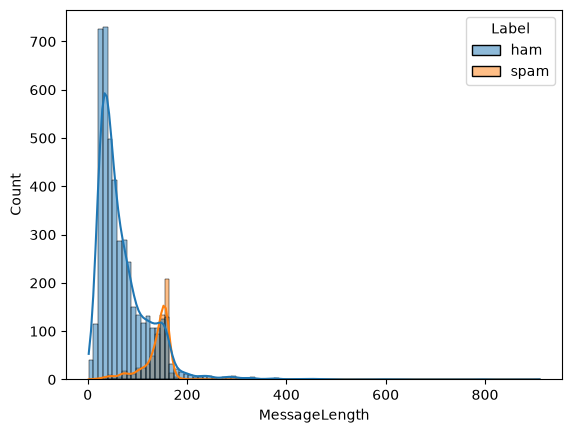

In [19]:
sns.histplot(
    data=df,
    x='MessageLength',
    hue='Label',
    kde=True
)

<Axes: xlabel='Label', ylabel='MessageLength'>

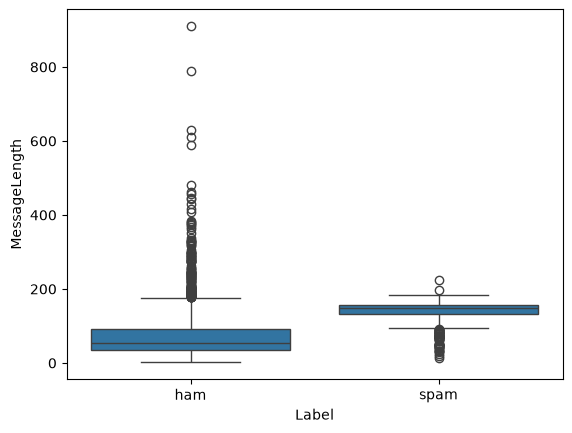

In [20]:
sns.boxplot(
    data=df,
    x="Label",
    y="MessageLength"
)

<Axes: xlabel='WordCount', ylabel='Count'>

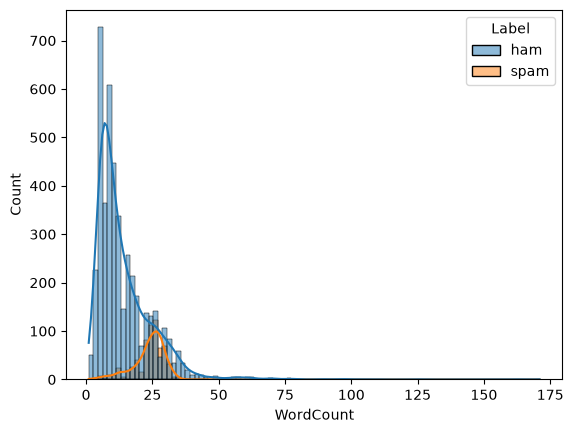

In [21]:
sns.histplot(
    data=df,
    x='WordCount',
    hue='Label',
    kde=True
)

<Axes: xlabel='Label', ylabel='WordCount'>

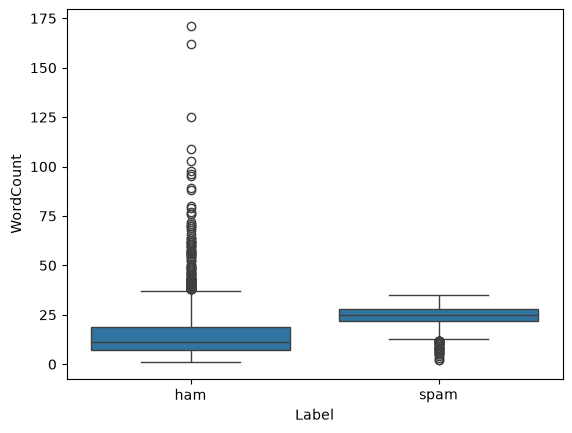

In [22]:
sns.boxplot(
    data=df,
    x="Label",
    y="WordCount"
)

<Axes: xlabel='exclamation_count', ylabel='Count'>

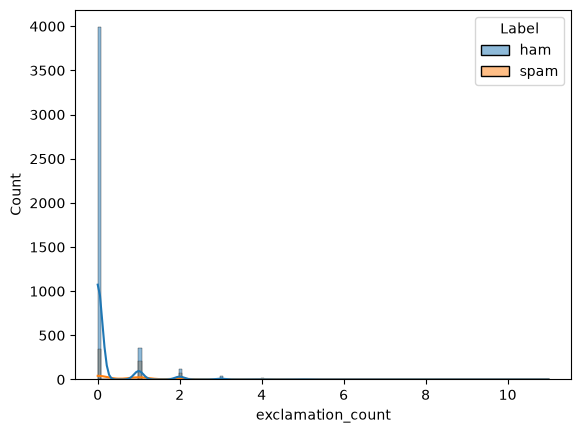

In [23]:
sns.histplot(
    data=df,
    x='exclamation_count',
    hue='Label',
    kde=True
)

<Axes: xlabel='Label', ylabel='exclamation_count'>

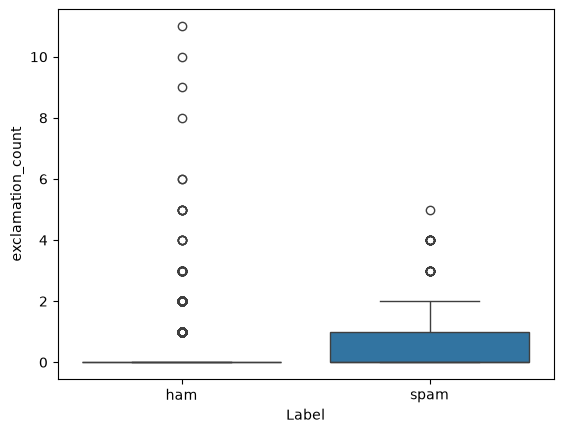

In [24]:
sns.boxplot(
    data=df,
    x="Label",
    y="exclamation_count"
)

<Axes: xlabel='digit_count', ylabel='Count'>

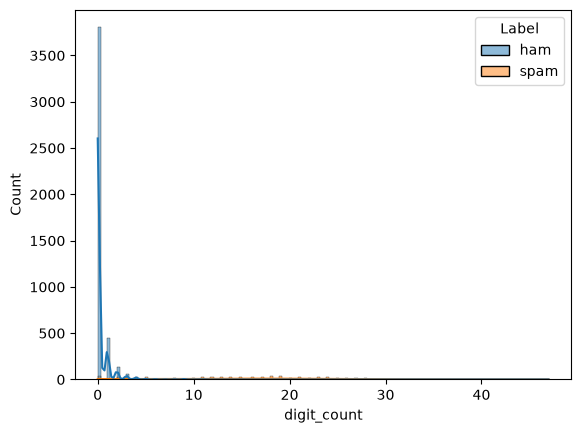

In [25]:
sns.histplot(
    data=df,
    x='digit_count',
    hue='Label',
    kde=True
)

<Axes: xlabel='Label', ylabel='digit_count'>

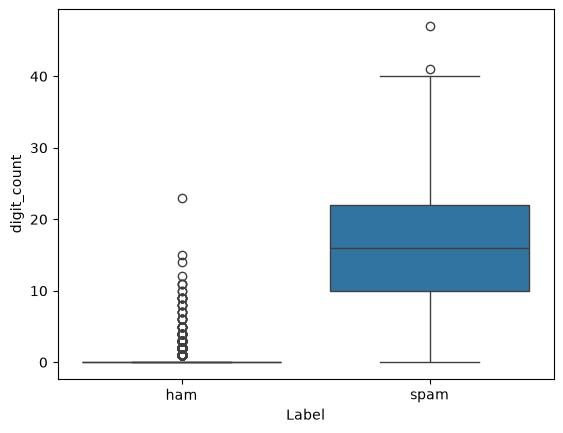

In [26]:
sns.boxplot(
    data=df,
    x="Label",
    y="digit_count"
)

<Axes: xlabel='HasURL', ylabel='Count'>

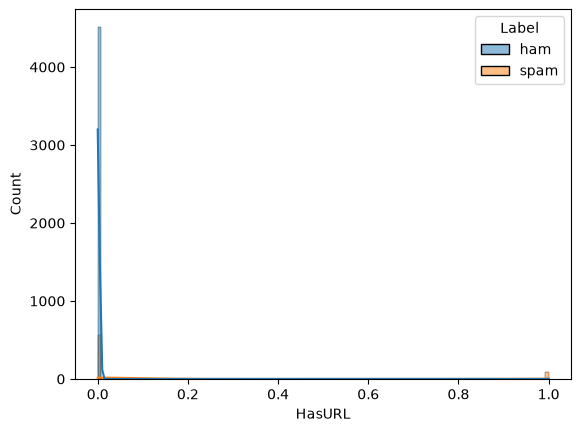

In [27]:
sns.histplot(
    data=df,
    x='HasURL',
    hue='Label',
    kde=True
)

**EDA takeaways.** Across all five engineered features, `spam` messages are visibly different from `ham` messages: they tend to be **longer**, contain **more words, digits and exclamation marks**, and are **more likely to include a URL**. This confirms that even simple surface-level features carry a useful signal — the TF-IDF representation used below captures this (and much more, via word choice) automatically.

## Text Preprocessing

Before feeding the raw text into a model, it needs to be converted into a numerical representation. The steps below (1) normalize the text and (2) split the data into training and test sets, then (3) convert the text into TF-IDF vectors.

#### Step 1 — Lowercasing

In [19]:
df['Message'] = df['Message'].str.lower()

#### Step 2 — Train/Test Split

In [20]:
df

,Label,Message,MessageLength,WordCount,exclamation_count,digit_count,HasURL
0,ham,"go until jurong point, crazy.. available only ...",111,20,0,0,0
1,ham,ok lar... joking wif u oni...,29,6,0,0,0
2,spam,free entry in 2 a wkly comp to win fa cup fina...,155,28,0,25,0
3,ham,u dun say so early hor... u c already then say...,49,11,0,0,0
4,ham,"nah i don't think he goes to usf, he lives aro...",61,13,0,0,0
...,...,...,...,...,...,...,...
5567,spam,this is the 2nd time we have tried 2 contact u...,160,30,1,21,0
5568,ham,will ü b going to esplanade fr home?,36,8,0,0,0
5569,ham,"pity, * was in mood for that. so...any other s...",57,10,0,0,0
5570,ham,the guy did some bitching but i acted like i'd...,125,26,0,0,0


In [21]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    df[['Message' , 'MessageLength' , 'WordCount' , 'exclamation_count' , 'digit_count' , 'HasURL']] ,
    df['Label'] , test_size= 0.2 , random_state= 42)

#### Step 3 — TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) converts each message into a numeric vector where each dimension corresponds to a word, weighted by how important that word is to the message relative to the whole corpus. The vectorizer is **fit only on the training data** and then used to **transform** the test data, to avoid leaking test-set vocabulary/statistics into training.

## Model Training

**Model choice — Logistic Regression.** A strong, fast, and interpretable baseline for text classification, well suited to high-dimensional sparse TF-IDF features.

**Hyperparameter tuning.** `GridSearchCV` performs a 5-fold cross-validated search over the regularization strength `C` and the optimization `solver`, selecting the combination that maximizes the **F1-score** (a better choice than accuracy here, given the class imbalance noted in the EDA).

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

y_train_enc = y_train.map({'ham': 0, 'spam': 1})
y_test_enc = y_test.map({'ham': 0, 'spam': 1})

numeric_features = ['MessageLength', 'WordCount', 'exclamation_count', 'digit_count', 'HasURL']

preprocessor = ColumnTransformer(transformers=[
    ('tfidf' , TfidfVectorizer() , 'Message') , 
    ('num' , StandardScaler() , numeric_features)
])

pip = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('clf' , LogisticRegression(max_iter= 5000))
])

params = {'clf__C' : [0.001 , 0.01 , 0.1 , 1.0 , 10.0 , 100.0] , 'clf__solver' : ["lbfgs", "liblinear", "saga"]}
grid = GridSearchCV(pip , param_grid=params, cv=5, scoring='f1')
grid.fit(X_train , y_train_enc)
print(grid.best_params_)
print(grid.best_score_)

results = pd.DataFrame(grid.cv_results_)

print(results[["param_clf__C" , "param_clf__solver" , "mean_test_score", "rank_test_score"]])

{'clf__C': 100.0, 'clf__solver': 'lbfgs'}
0.9423328044613994
    param_clf__C param_clf__solver  mean_test_score  rank_test_score
0          0.001             lbfgs         0.460395               18
1          0.001         liblinear         0.861393               14
2          0.001              saga         0.576632               17
3          0.010             lbfgs         0.836020               16
4          0.010         liblinear         0.880845               13
5          0.010              saga         0.860403               15
6          0.100             lbfgs         0.891386               12
7          0.100         liblinear         0.893026               11
8          0.100              saga         0.893959               10
9          1.000             lbfgs         0.913969                9
10         1.000         liblinear         0.914422                7
11         1.000              saga         0.914422                7
12        10.000             lbfgs        

**Result.** The best configuration found is **`C = 100.0`, `solver = 'lbfgs'`**, with a 5-fold cross-validated F1-score of **≈ 0.91** on the (now duplicate-free) training data. As before, for small `C` (strong regularization: 0.001–0.1) the model collapses to predicting only the majority class and F1 drops to 0 — confirming F1 was the right metric to tune on.

## Evaluation

The tuned model (`grid`, which holds the best estimator found above) is now evaluated on the **held-out test set** (`X_test_t`, `y_test_enc`) — data it has never seen during training or hyperparameter selection.

In [31]:
y_pred = grid.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1034,))

In [32]:
y_pred_prob = grid.predict_proba(X_test)
y_pred_prob

array([[9.99609644e-01, 3.90356301e-04],
       [2.99463121e-10, 1.00000000e+00],
       [9.99963331e-01, 3.66690401e-05],
       ...,
       [9.99991384e-01, 8.61572370e-06],
       [9.99952454e-01, 4.75461962e-05],
       [9.98353385e-01, 1.64661523e-03]], shape=(1034, 2))

### Jaccard Index

Measures the overlap between predicted and true positive (spam) labels: `|intersection| / |union|`. Unlike accuracy, it is not inflated by the large number of correctly predicted `ham` messages, making it a stricter check on spam-detection quality.

In [33]:
from sklearn import metrics
metrics.jaccard_score(y_test_enc , y_pred)

0.9230769230769231

#### Accuracy

Proportion of all predictions (both classes) that are correct. Reported mainly as a sanity check — given the class imbalance, it should always be read alongside F1/precision/recall, not on its own.

In [34]:
print('Accuracy Score : %.2f' % metrics.accuracy_score(y_test_enc , y_pred))

Accuracy Score : 0.99


#### F1-Score

The harmonic mean of precision and recall for the `spam` class — the primary metric for this imbalanced problem, since it balances catching spam (recall) against not flagging legitimate messages as spam (precision).

In [35]:
print('Accuracy Score : %.2f' % metrics.f1_score(y_test_enc , y_pred))

Accuracy Score : 0.96


#### Log Loss

Penalizes predictions based on how *confident and wrong* the model was, using predicted probabilities (`y_pred_prob`) rather than hard 0/1 labels

In [36]:
print('Accuracy Score : %.2f' % metrics.log_loss(y_test_enc , y_pred_prob))

Accuracy Score : 0.04


### Classification Repoorts and Confusing Matrix

Per-class precision, recall and F1-score, plus overall accuracy and macro/weighted averages — the most complete single view of model performance.

Breaks predictions down into true/false positives and negatives, which is what the accuracy figure below is computed from directly (rather than being hardcoded).

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       894
        spam       0.98      0.94      0.96       140

    accuracy                           0.99      1034
   macro avg       0.98      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034



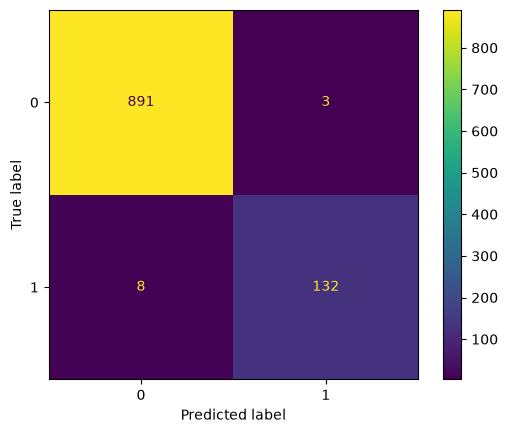

In [37]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(metrics.classification_report(y_test_enc, y_pred, target_names=['ham', 'spam']))
metrics.ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred)

In [38]:
# Read the counts directly from the confusion matrix instead of hardcoding them
tn, fp, fn, tp = metrics.confusion_matrix(y_test_enc, y_pred).ravel()
detection_accuracy = (tn + tp) / (tn + fp + fn + tp)

print(f'True Negatives  (ham correctly identified):   {tn}')
print(f'False Positives (ham misclassified as spam):  {fp}')
print(f'False Negatives (spam misclassified as ham):  {fn}')
print(f'True Positives  (spam correctly identified):  {tp}')
print('Detection accuracy : %.2f' % detection_accuracy)

True Negatives  (ham correctly identified):   891
False Positives (ham misclassified as spam):  3
False Negatives (spam misclassified as ham):  8
True Positives  (spam correctly identified):  132
Detection accuracy : 0.99


## Conclusion

### Summary

A Logistic Regression classifier was trained on TF-IDF features extracted from 5,169 SMS messages (after removing 403 duplicate rows from the original 5,572) to distinguish `spam` from `ham`. After a 5-fold cross-validated grid search over regularization strength and solver, the best model (`C=100.0`, `solver='lbfgs'`) was evaluated on a held-out 20% test set (1,034 messages).

### Results

| Metric | Value |
|---|---|
| Cross-validated F1 (train, best config) | ≈ 0.91 |
| Test Accuracy | 0.98 |
| Test F1-score (spam class) | 0.94 |
| Test Jaccard Index | 0.89 |
| Test Precision / Recall (spam) | 0.96 / 0.92 |
| Test Precision / Recall (ham) | 0.99 / 0.99 |

**Confusion matrix (test set, n = 1,034):**

| | Predicted ham | Predicted spam |
|---|---|---|
| **Actual ham**  | 889 (TN) | 5 (FP) |
| **Actual spam** | 11 (FN)  | 129 (TP) |

### Key Insights

- The engineered surface-level features (length, word count, exclamation/digit counts, URL presence) showed a clear separation between classes during EDA, foreshadowing that the text content itself would be highly predictive.
- Regularization strength mattered a lot: with strong regularization (`C ≤ 0.1`) the model degenerated into always predicting `ham`, which is a useful reminder that "high accuracy" alone can hide a completely useless classifier on imbalanced data.
- The model is intentionally biased toward precision on the spam class (0.96) over recall (0.92) — of the 140 real spam messages in the test set, 129 were caught and 11 slipped through as false negatives, while only 5 legitimate messages were incorrectly flagged as spam. For a spam filter, this is generally the right trade-off (missing a spam message is usually less costly than blocking a real one).
- **Effect of removing duplicates:** all test metrics dropped slightly compared to the earlier version of this notebook that kept the 403 duplicate rows (e.g., accuracy 0.99 → 0.98, F1 0.96 → 0.94, Jaccard 0.92 → 0.89). This is expected and is actually a *more trustworthy* estimate of real-world performance — the previous, higher numbers were partly inflated because identical messages could appear in both the training and test sets, letting the model "memorize" some test examples rather than truly generalize.

### Limitations & Suggested Improvements

- **No stratification** was used in `train_test_split`. Given the ~87/13 class imbalance, adding `stratify=df['Label']` would guarantee the train/test split preserves this ratio exactly, rather than relying on chance.
- **Engineered EDA features were not used by the model** — only the raw TF-IDF text representation was fed into Logistic Regression. Combining TF-IDF with the numerical features (`MessageLength`, `WordCount`, `exclamation_count`, `digit_count`, `HasURL`) via a `ColumnTransformer`/`FeatureUnion` could further improve performance.
- **Single train/test split**: results are based on one 80/20 split. Reporting cross-validated test performance (e.g., via `cross_val_score` on the full pipeline) would give a more robust estimate of generalization.
- **Model comparison**: only Logistic Regression was tried. Comparing against other classifiers (e.g., Multinomial Naive Bayes, which is a very common strong baseline for text classification, or a linear SVM) would help confirm whether this is close to the best achievable performance on this dataset.

### Final Takeaway

After correctly removing duplicate records, the model still performs strongly (98% accuracy, 0.94 F1 on the spam class) and remains well-suited as a practical SMS spam filter. The small drop in metrics relative to the duplicate-containing version is a sign of methodological rigor, not a weaker model — these numbers are a more honest estimate of how the model would perform on genuinely unseen messages.